#Air Quality Prediction: Regression Model
# AI Project - FAST NUCES Lahore | BCS-4D
*Team:* Muhammad Izaan (24L-0819) · Muhammad Shaban (23L-0768) · Hussain Mushtaq (24L-0771)

**Goal:** Predict the Overall AQI Value of a city using pollutant concentrations (Regression),  
and find the closest matching city from the dataset based on input pollutant levels.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries imported.')

Libraries imported.


## 2. Data Loading & Description

In [4]:
df = pd.read_csv('Air_Quality_Dataset (1).csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 23,035 rows × 15 columns


,Country,City,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,AQI Value,Overall AQI Value,Overall AQI Rating,Country_Code,City_Code
0,Afghanistan,Acin,0.000000,Good,0.195745,Good,0.000000,Good,0.124,Moderate,0.113360,0.143704,Good,0,102
1,Afghanistan,Anar Darreh,0.007519,Good,0.178723,Good,0.000000,Good,0.252,Unhealthy for Sensitive Groups,0.242915,0.234074,Good,0,685
2,Afghanistan,Andarab,0.000000,Good,0.144681,Good,0.000000,Good,0.208,Unhealthy for Sensitive Groups,0.198381,0.188148,Good,0,695
3,Afghanistan,Asadabad,0.007519,Good,0.182979,Good,0.000000,Good,0.262,Unhealthy for Sensitive Groups,0.253036,0.242963,Good,0,1044
4,Afghanistan,Asmar,0.015038,Good,0.204255,Good,0.010989,Good,0.302,Unhealthy,0.293522,0.282963,Moderate,0,1093


In [5]:
print('=== Column Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Column Data Types ===
Country                object
City                   object
CO AQI Value          float64
CO AQI Category        object
Ozone AQI Value       float64
Ozone AQI Category     object
NO2 AQI Value         float64
NO2 AQI Category       object
PM2.5 AQI Value       float64
PM2.5 AQI Category     object
AQI Value             float64
Overall AQI Value     float64
Overall AQI Rating     object
Country_Code            int64
City_Code               int64
dtype: object

=== Missing Values ===
Country               0
City                  0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
AQI Value             0
Overall AQI Value     0
Overall AQI Rating    0
Country_Code          0
City_Code             0
dtype: int64

Total missing: 0


In [6]:
print('=== Statistical Summary (Numerical Features) ===')
df.describe().round(4)

=== Statistical Summary (Numerical Features) ===


,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,AQI Value,Overall AQI Value,Country_Code,City_Code
count,23035.0000,23035.0000,23035.0000,23035.0000,23035.0000,23035.0000,23035.0000,23035.0000
mean,0.0103,0.1499,0.0339,0.1378,0.1343,0.1446,92.4485,11517.0000
std,0.0139,0.1202,0.0580,0.1101,0.1141,0.1061,50.3147,6649.7761
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0075,0.0894,0.0000,0.0700,0.0668,0.0815,58.0000,5758.5000
50%,0.0075,0.1319,0.0110,0.1080,0.0992,0.1156,75.0000,11517.0000
75%,0.0075,0.1702,0.0440,0.1580,0.1498,0.1585,136.0000,17275.5000
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,174.0000,23034.0000


#Data

In [7]:
df = df.dropna(subset=['Country', 'City'])

before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df):,}')

FEATURES = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
TARGET   = 'Overall AQI Value'
print('\nNull counts in model columns:')
print(df[FEATURES + [TARGET]].isnull().sum())

Removed 0 duplicate rows. Remaining: 23,035

Null counts in model columns:
CO AQI Value         0
Ozone AQI Value      0
NO2 AQI Value        0
PM2.5 AQI Value      0
Overall AQI Value    0
dtype: int64


In [8]:
print('=== IQR-based Outlier Count (kept in dataset) ===')
for col in FEATURES + [TARGET]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col}: {n} outliers')

=== IQR-based Outlier Count (kept in dataset) ===
  CO AQI Value: 8442 outliers
  Ozone AQI Value: 1500 outliers
  NO2 AQI Value: 1936 outliers
  PM2.5 AQI Value: 2628 outliers
  Overall AQI Value: 2429 outliers


*observing dataset*

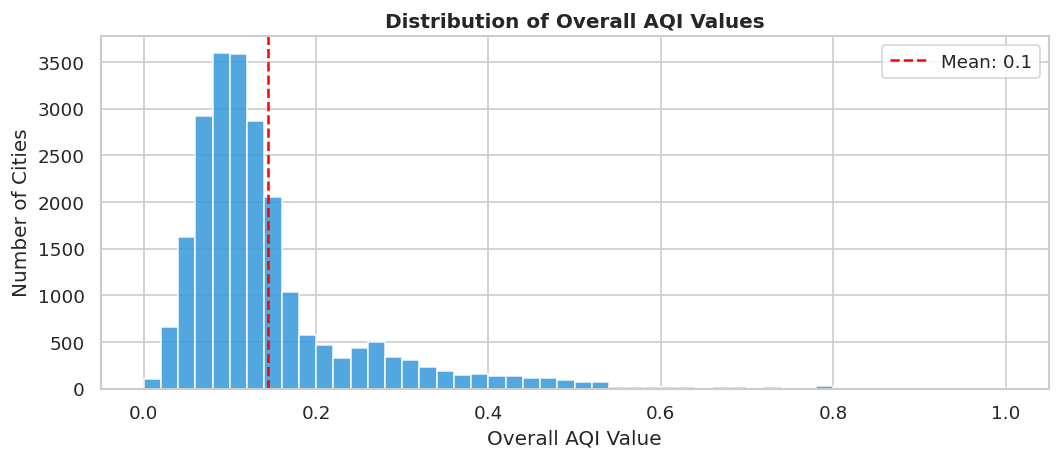

In [9]:
plt.figure(figsize=(9, 4))
plt.hist(df['Overall AQI Value'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(df['Overall AQI Value'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean: {df['Overall AQI Value'].mean():.1f}")
plt.xlabel('Overall AQI Value')
plt.ylabel('Number of Cities')
plt.title('Distribution of Overall AQI Values', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('aqi_distribution.png', bbox_inches='tight')
plt.show()

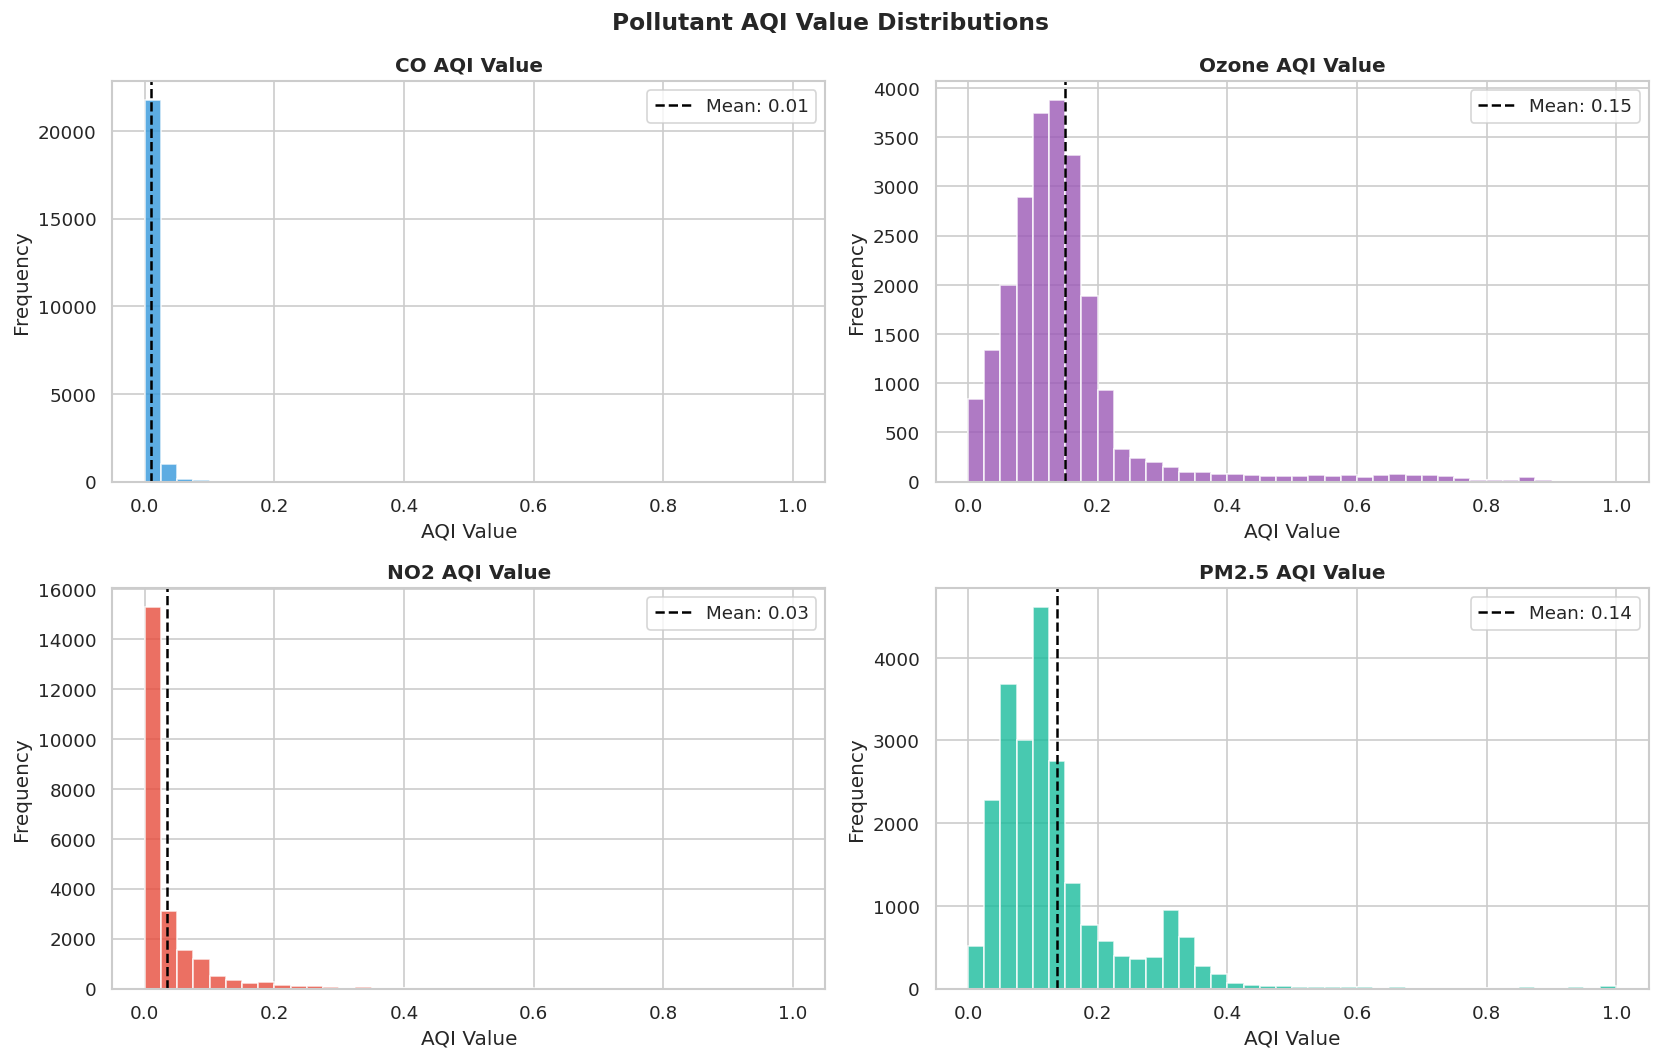

In [10]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = ['#3498db', '#9b59b6', '#e74c3c', '#1abc9c']
for ax, col, color in zip(axes.flat, FEATURES, colors):
    ax.hist(df[col], bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('AQI Value')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.suptitle('Pollutant AQI Value Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pollutant_distributions.png', bbox_inches='tight')
plt.show()

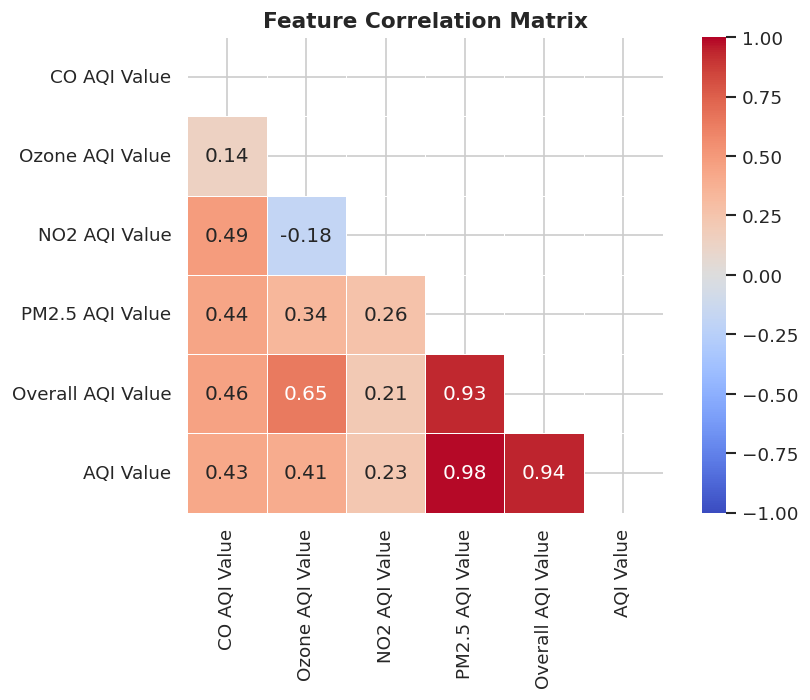

In [11]:
num_cols = FEATURES + [TARGET, 'AQI Value']
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

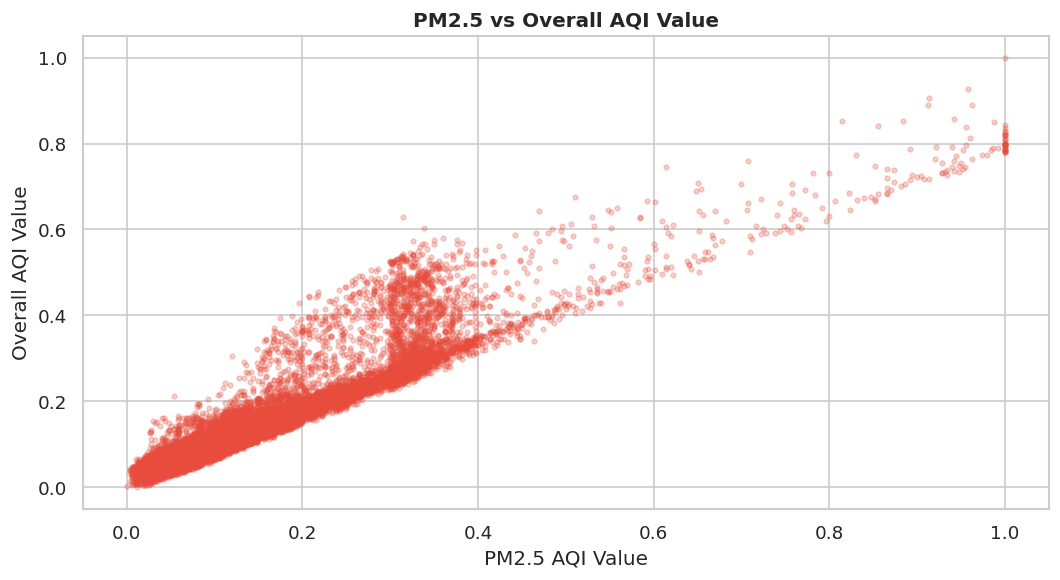

In [12]:
plt.figure(figsize=(9, 5))
plt.scatter(df['PM2.5 AQI Value'], df['Overall AQI Value'],
            alpha=0.25, s=8, color='#e74c3c')
plt.xlabel('PM2.5 AQI Value', fontsize=12)
plt.ylabel('Overall AQI Value', fontsize=12)
plt.title('PM2.5 vs Overall AQI Value', fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_pm25_aqi.png', bbox_inches='tight')
plt.show()

#*train and split data*


In [13]:
FEATURES = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
TARGET   = 'Overall AQI Value'

X = df[FEATURES].values
y = df[TARGET].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing  samples : {X_test.shape[0]:,}')
print(f'Features         : {FEATURES}')

Training samples : 18,428
Testing  samples : 4,607
Features         : ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']


#Regression

#Linear regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr_pred = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_lr_pred))
r2_lr   = r2_score(y_test, y_lr_pred)

print('=== Linear Regression ===')
print(f'  MAE  : {mae_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')
print(f'  R²   : {r2_lr:.4f}')

=== Linear Regression ===
  MAE  : 0.0000
  RMSE : 0.0000
  R²   : 1.0000


#Random Forest

In [15]:
rfr = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rfr.fit(X_train, y_train)
y_rfr_pred = rfr.predict(X_test)

mae_rfr  = mean_absolute_error(y_test, y_rfr_pred)
rmse_rfr = np.sqrt(mean_squared_error(y_test, y_rfr_pred))
r2_rfr   = r2_score(y_test, y_rfr_pred)

print('=== Random Forest Regressor ===')
print(f'  MAE  : {mae_rfr:.4f}')
print(f'  RMSE : {rmse_rfr:.4f}')
print(f'  R²   : {r2_rfr:.4f}')

=== Random Forest Regressor ===
  MAE  : 0.0014
  RMSE : 0.0036
  R²   : 0.9989


#model Evaluation

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE':   [mae_lr,   mae_rfr],
    'RMSE':  [rmse_lr,  rmse_rfr],
    'R²':    [r2_lr,    r2_rfr]
}).set_index('Model').round(4)

print('=== Regression Model Comparison ===')
print(results.to_string())

print(f'\nBest model: Random Forest Regressor (R² = {r2_rfr:.4f})')

=== Regression Model Comparison ===
                            MAE    RMSE      R²
Model                                          
Linear Regression        0.0000  0.0000  1.0000
Random Forest Regressor  0.0014  0.0036  0.9989

Best model: Random Forest Regressor (R² = 0.9989)


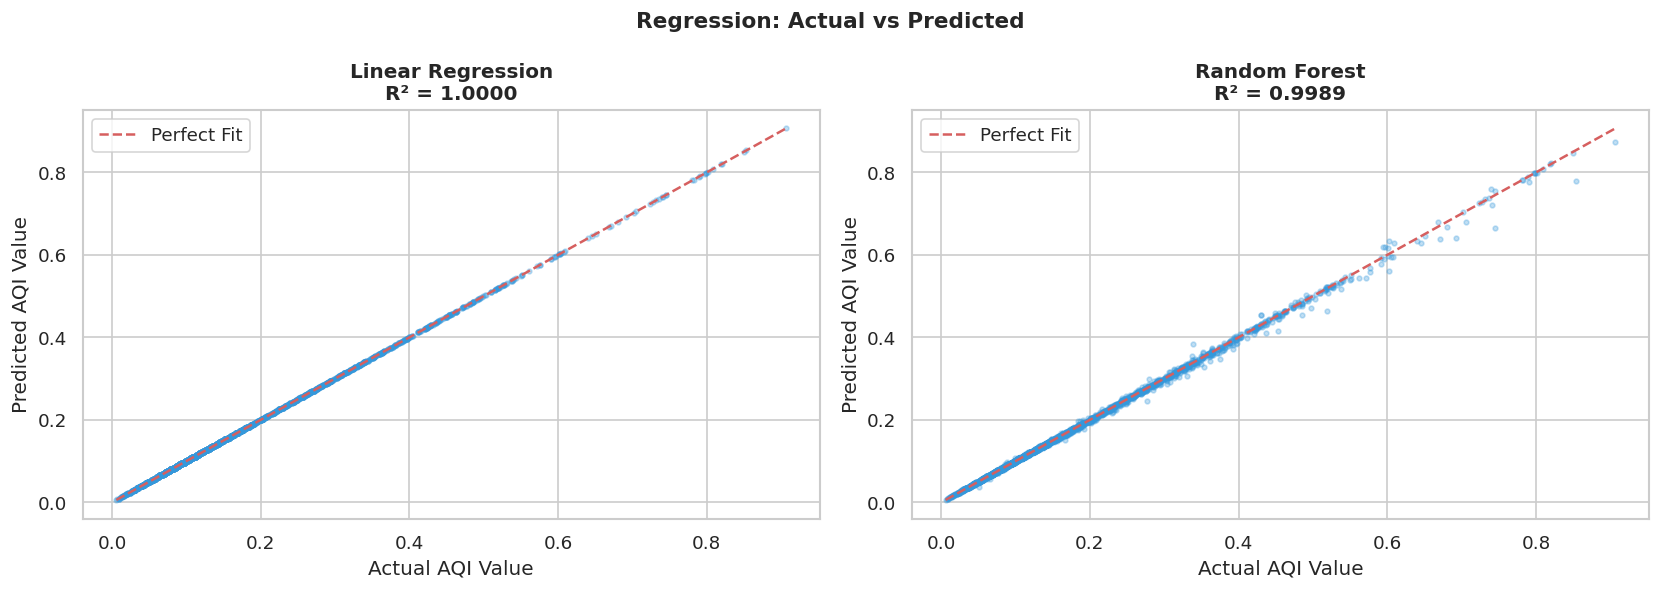

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_plot = [('Linear Regression', y_lr_pred, r2_lr),
               ('Random Forest',     y_rfr_pred, r2_rfr)]

for ax, (name, preds, r2) in zip(axes, models_plot):
    ax.scatter(y_test, preds, alpha=0.3, s=8, color='#3498db')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual AQI Value')
    ax.set_ylabel('Predicted AQI Value')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend()

plt.suptitle('Regression: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

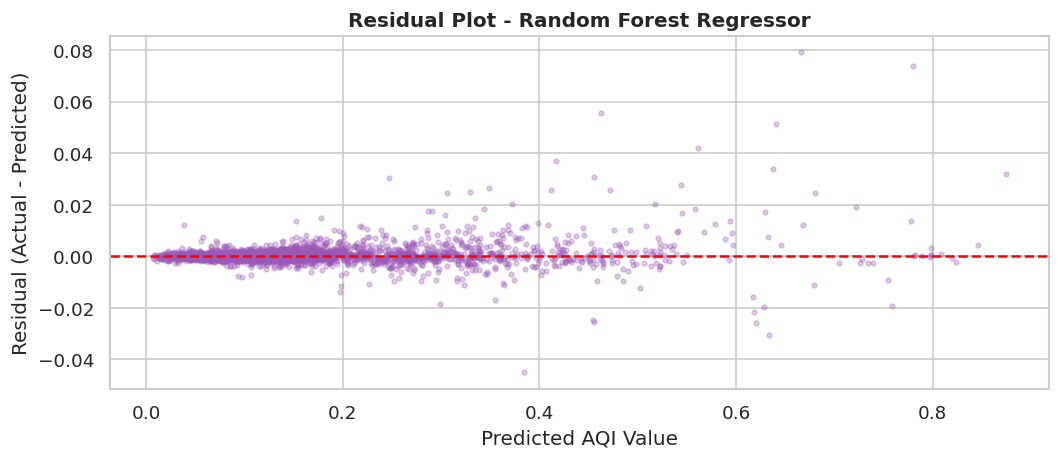

In [18]:
residuals = y_test - y_rfr_pred
plt.figure(figsize=(9, 4))
plt.scatter(y_rfr_pred, residuals, alpha=0.3, s=8, color='#9b59b6')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted AQI Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot - Random Forest Regressor', fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plot.png', bbox_inches='tight')
plt.show()

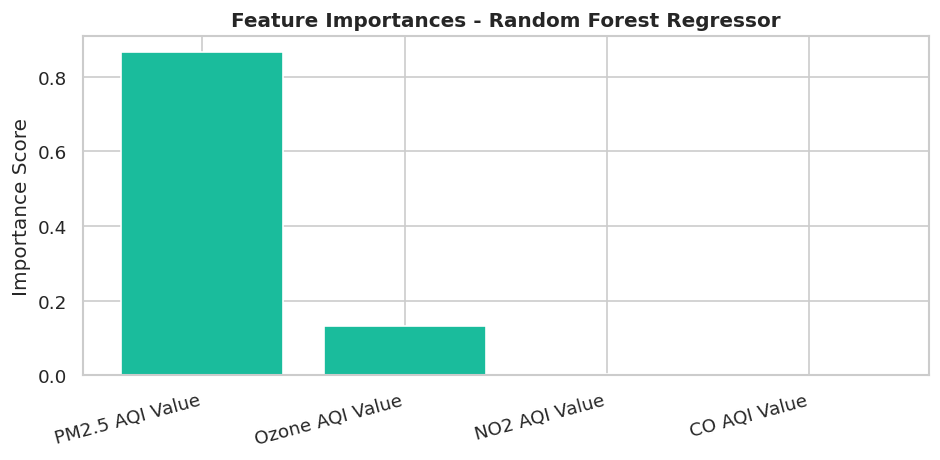

  PM2.5 AQI Value: 0.8653
  Ozone AQI Value: 0.1312
  NO2 AQI Value: 0.0027
  CO AQI Value: 0.0007


In [19]:
importances = rfr.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 4))
plt.bar(range(len(FEATURES)), importances[idx], color='#1abc9c', edgecolor='white')
plt.xticks(range(len(FEATURES)), [FEATURES[i] for i in idx], rotation=15, ha='right')
plt.ylabel('Importance Score')
plt.title('Feature Importances - Random Forest Regressor', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
for i in idx:
    print(f'  {FEATURES[i]}: {importances[i]:.4f}')

#City Finder              |                        Closest Matching City
Given a set of pollutant AQI values find the real city in the dataset whose pollution profile is most similar

In [20]:
from scipy.spatial.distance import cdist

def find_closest_city(co, ozone, no2, pm25, top_n=5):

    input_vec = np.array([[co, ozone, no2, pm25]])
    dataset_vec = df[FEATURES].values
    distances = cdist(input_vec, dataset_vec, metric='euclidean')[0]
    top_idx = np.argsort(distances)[:top_n]
    result = df.iloc[top_idx][['City', 'Country'] + FEATURES + ['Overall AQI Value', 'Overall AQI Rating']].copy()
    result['Distance'] = distances[top_idx].round(2)
    return result.reset_index(drop=True)

print('=== Example: Lahore-like input (CO=1, Ozone=40, NO2=20, PM2.5=180) ===')
find_closest_city(co=1, ozone=40, no2=20, pm25=180)

=== Example: Lahore-like input (CO=1, Ozone=40, NO2=20, PM2.5=180) ===


,City,Country,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,Overall AQI Value,Overall AQI Rating,Distance
0,Aonla,India,0.030075,0.634043,0.043956,0.958,0.925926,Unhealthy,184.40
1,Puranpur,India,0.015038,0.544681,0.010989,0.962,0.890370,Unhealthy,184.42
2,Barkhera,India,0.015038,0.374468,0.010989,0.988,0.850370,Unhealthy for Sensitive Groups,184.43
3,Gunnaur,India,0.007519,0.310638,0.010989,1.000,0.835556,Unhealthy for Sensitive Groups,184.44
4,Bilari,India,0.030075,0.672340,0.043956,0.914,0.906667,Unhealthy,184.44


## 9. Save Model & Scaler
Save the trained Random Forest Regressor and scaler as model.pkl and scaler.pkl  
so the Flask web app can load and use them.

In [21]:
with open('model.pkl', 'wb') as f:
    pickle.dump(rfr, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

df[['City', 'Country'] + FEATURES + ['Overall AQI Value', 'Overall AQI Rating']].to_csv('cities_lookup.csv', index=False)

print('model.pkl saved')
print('scaler.pkl saved')
print('cities_lookup.csv saved')

model.pkl saved
scaler.pkl saved
cities_lookup.csv saved


## 10. Final Summary

In [22]:
print('=' * 55)
print('   REGRESSION MODEL EVALUATION SUMMARY')
print('=' * 55)
print(results.to_string())
print('\n-- KEY OBSERVATIONS --')
print(f'Best Model : Random Forest Regressor')
print(f'R^2 : {r2_rfr:.4f}  (explains {r2_rfr*100:.1f}% of variance)')
print(f'MAE : {mae_rfr:.4f}  (avg error ≈ {mae_rfr:.1f} AQI points)')
print(f'RMSE : {rmse_rfr:.4f}')
print(f'PM2.5 is the strongest predictor of overall AQI')
print(f'Model saved as model.pkl')

   REGRESSION MODEL EVALUATION SUMMARY
                            MAE    RMSE      R²
Model                                          
Linear Regression        0.0000  0.0000  1.0000
Random Forest Regressor  0.0014  0.0036  0.9989

-- KEY OBSERVATIONS --
Best Model : Random Forest Regressor
R^2 : 0.9989  (explains 99.9% of variance)
MAE : 0.0014  (avg error ≈ 0.0 AQI points)
RMSE : 0.0036
PM2.5 is the strongest predictor of overall AQI
Model saved as model.pkl
